In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import sklearn
import statsmodels

In [3]:
df = pd.read_csv("../data/nifty50_daily.csv")
df.head()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
0,2015-11-09,7788.25,7937.75,7771.70,7915.20,218422388.0,9376.17
1,2015-11-10,7877.60,7885.10,7772.85,7783.35,170267413.0,7153.47
2,2015-11-11,7838.80,7847.95,7819.10,7825.00,22380435.0,1123.44
3,2015-11-13,7762.45,7775.10,7730.90,7762.25,165876819.0,7731.55
4,2015-11-16,7732.95,7838.85,7714.15,7806.60,154134885.0,6871.15


In [4]:
df["Date"] = pd.to_datetime(df["Date"])
df = df.sort_values("Date").reset_index(drop=True)

df.tail()

,Date,Open,High,Low,Close,Shares Traded,Turnover (₹ Cr)
2143,2024-07-08,24329.45,24344.60,24240.55,24320.55,266299131.0,26356.03
2144,2024-07-09,24351.00,24443.60,24331.90,24433.20,250537091.0,29361.08
2145,2024-07-10,24459.85,24461.05,24141.80,24324.45,292263786.0,35358.54
2146,2024-07-11,24396.55,24402.65,24193.75,24315.95,306404194.0,32115.44
2147,2024-07-12,24387.95,24592.20,24331.15,24502.15,325823474.0,39565.33


In [28]:
df["LogReturn"] = np.log(df["Close"] / df["Close"].shift(1))
df = df.dropna().reset_index(drop=True)

In [29]:
features = [
    "Open",
    "High",
    "Low",
    "Close",
    "Shares Traded",
    "Turnover (₹ Cr)"
]

target = "LogReturn"

X = df[features]
y = df[target]

In [30]:
train_end = "2021-12-31"
val_end = "2023-12-31"

X_train = X[df["Date"] <= train_end]
y_train = y[df["Date"] <= train_end]

X_val = X[(df["Date"] > train_end) & (df["Date"] <= val_end)]
y_val = y[(df["Date"] > train_end) & (df["Date"] <= val_end)]

X_test = X[df["Date"] > val_end]
y_test = y[df["Date"] > val_end]

len(X_train), len(X_val), len(X_test)

(1520, 494, 133)

In [34]:
# Naive baseline for returns: predict zero
y_pred_naive = np.zeros_like(y_test)

In [36]:
from sklearn.metrics import mean_squared_error, mean_absolute_error
import numpy as np

rmse_naive = np.sqrt(mean_squared_error(y_test, y_pred_naive))
mae_naive = mean_absolute_error(y_test, y_pred_naive)

rmse_naive, mae_naive

(np.float64(0.009459609916929484), 0.006052257297191653)

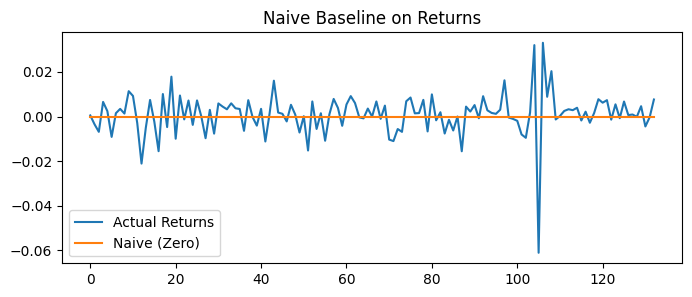

In [38]:
plt.figure(figsize=(8, 3))
plt.plot(y_test.values, label="Actual Returns")
plt.plot(y_pred_naive, label="Naive (Zero)")
plt.title("Naive Baseline on Returns")
plt.legend()
plt.show()

Linear Regression

In [39]:
MAX_LAG = 5

df_lr = df.copy()

for lag in range(1, MAX_LAG + 1):
    df_lr[f"LogReturn_lag_{lag}"] = df_lr["LogReturn"].shift(lag)

df_lr = df_lr.dropna().reset_index(drop=True)

In [40]:
feature_cols = [f"LogReturn_lag_{i}" for i in range(1, MAX_LAG + 1)]

X_lr = df_lr[feature_cols]
y_lr = df_lr["LogReturn"]
dates_lr = df_lr["Date"]

In [41]:
X_train_lr = X_lr[dates_lr <= train_end]
y_train_lr = y_lr[dates_lr <= train_end]

X_val_lr = X_lr[(dates_lr > train_end) & (dates_lr <= val_end)]
y_val_lr = y_lr[(dates_lr > train_end) & (dates_lr <= val_end)]

X_test_lr = X_lr[dates_lr > val_end]
y_test_lr = y_lr[dates_lr > val_end]

In [42]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()
lr_model.fit(X_train_lr, y_train_lr)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [43]:
y_pred_lr = lr_model.predict(X_test_lr)

rmse_lr = np.sqrt(mean_squared_error(y_test_lr, y_pred_lr))
mae_lr = mean_absolute_error(y_test_lr, y_pred_lr)

rmse_lr, mae_lr

(np.float64(0.009471952021217318), 0.00620588401178845)

In [44]:
pd.Series(lr_model.coef_, index=feature_cols)

LogReturn_lag_1   -0.038381
LogReturn_lag_2    0.022709
LogReturn_lag_3    0.018323
LogReturn_lag_4   -0.006331
LogReturn_lag_5    0.123548
dtype: float64

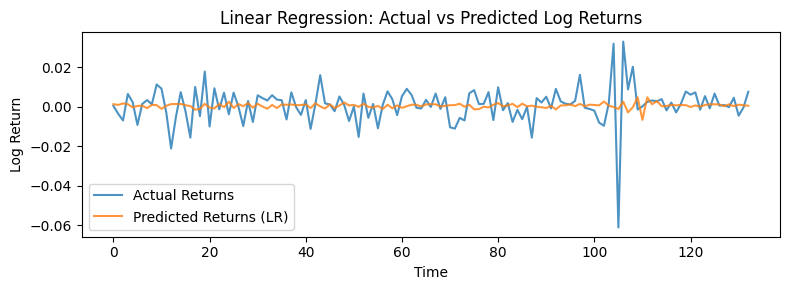

In [53]:
plt.figure(figsize=(8, 3))
plt.plot(y_test_lr.values, label="Actual Returns", alpha=0.8)
plt.plot(y_pred_lr, label="Predicted Returns (LR)", alpha=0.8)

plt.title("Linear Regression: Actual vs Predicted Log Returns")
plt.xlabel("Time")
plt.ylabel("Log Return")
plt.legend()
plt.tight_layout()
plt.show()

ARIIMA

In [45]:
import numpy as np
import pandas as pd

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.arima.model import ARIMA

from sklearn.metrics import mean_squared_error, mean_absolute_error

In [46]:
df["log_return"] = np.log(df["Close"]).diff()
df = df.dropna()

df[["Date", "Close", "log_return"]].head()

,Date,Close,log_return
1,2015-11-11,7825.00,0.005337
2,2015-11-13,7762.25,-0.008051
3,2015-11-16,7806.60,0.005697
4,2015-11-17,7837.55,0.003957
5,2015-11-18,7731.80,-0.013585


In [47]:
p_value = adfuller(df["log_return"])[1]
p_value

np.float64(1.976881688109158e-23)

In [48]:
train_series = df.loc[df["Date"] <= train_end, "log_return"]
test_series  = df.loc[df["Date"] > val_end, "log_return"]

len(train_series), len(test_series)

(1519, 133)

In [60]:
arima_model = ARIMA(train_series, order=(1, 0, 1))
arima_result = arima_model.fit()

arima_result.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                               SARIMAX Results                                
==============================================================================
Dep. Variable:             log_return   No. Observations:                 1519
Model:                 ARIMA(1, 0, 1)   Log Likelihood                4666.934
Date:                Wed, 28 Jan 2026   AIC                          -9325.869
Time:                        23:58:46   BIC                          -9304.566
Sample:                             0   HQIC                         -9317.938
                               - 1519                                         
Covariance Type:                  opg                                         
==============================================================================
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.0005      0.000      1.714      0.087   -7.55e-05       0.001
ar.L1         -0.2382      0.201     -1.186      0.236      -0.632       0.156
ma.L1          0.1982      0.206      0.962      0.336      -0.205       0.602
sigma2         0.0001   1.68e-06     74.882      0.000       0.000       0.000
===================================================================================
Ljung-Box (L1) (Q):                   0.00   Jarque-Bera (JB):             34213.85
Prob(Q):                              1.00   Prob(JB):                         0.00
Heteroskedasticity (H):               3.91   Skew:                            -1.54
Prob(H) (two-sided):                  0.00   Kurtosis:                        26.05
===================================================================================

Warnings:
[1] Covariance matrix calculated using the outer product of gradients (complex-step).
"""

In [61]:
n_test = len(test_series)

arima_forecast = arima_result.forecast(steps=n_test)
arima_forecast.head()

1520    0.000195
1521    0.000604
1522    0.000506
1523    0.000529
1524    0.000524
Name: predicted_mean, dtype: float64

In [62]:
rmse_arima = np.sqrt(mean_squared_error(test_series, arima_forecast))
mae_arima = mean_absolute_error(test_series, arima_forecast)

rmse_arima, mae_arima

(np.float64(0.009424196451954586), 0.0059737107504526)

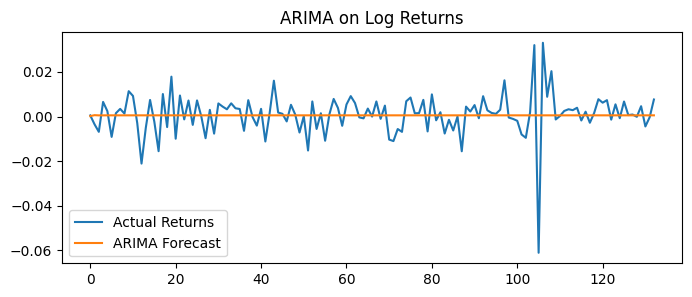

In [63]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 3))
plt.plot(test_series.values, label="Actual Returns")
plt.plot(arima_forecast.values, label="ARIMA Forecast")
plt.title("ARIMA on Log Returns")
plt.legend()
plt.show()